In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from newspaper import Article
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

data = pd.read_csv("sentiment_analysis.csv")

In [2]:
data.tail()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count,publisher_size,return_7d,return_30d,return_6m,article_text,finbert_label,finbert_score,sentiment_encoded
23903,UPDATE: J.P. Morgan Raises Price Target on Yum...,https://www.benzinga.com/analyst-ratings/analy...,Steven Anfield,2011-12-08,YUM,0,30,0,0.000174,0.037050,0.171840,"According to J.P. Morgan, Yum Brands (NYSE:\r\...",neutral,0.795712,0
23904,JP Morgan Raises PT on Yum Brands to $68,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-12-08,YUM,0,401,0,0.000174,0.037050,0.171840,© 2026 Benzinga.com. Benzinga does not provide...,neutral,0.939211,0
23905,YUM! Cites Dividends and Buybacks as Ways to R...,https://www.benzinga.com/news/11/12/2183552/yu...,Matthew Kennedy,2011-12-07,YUM,0,76,0,-0.011033,0.031718,0.160814,Never miss a trade again with the fastest news...,neutral,0.932860,0
23906,"Jefferies Reiterates Hold, $55 Target on Yum! ...",https://www.benzinga.com/analyst-ratings/analy...,Phil Marsh,2011-12-06,YUM,0,99,0,0.016571,0.036455,0.133400,Jefferies maintains its Hold rating and $55 ta...,positive,0.717313,1
23907,Yum! Brands Announces Full-Year 2012 Expectati...,https://www.benzinga.com/news/11/12/2174970/yu...,Matthew Kennedy,2011-12-05,YUM,1,76,0,0.032756,0.032930,0.135161,"Yum! Brands Inc. (NYSE:\r\nYUM), in advance of...",positive,0.948789,1


We spoke a lot in class about how the project is going in terms of scraping and sentiment analysis. A short summary is that we refined the goal of the project because most of the sentiment was labeled as neutral. I personally think neutral for a lot of articles is fine because the goal of the project is to classify authors based on performance so if they do not say anything meaningful in the article or state basic information as if nothing interesting is happening, then the stock should stay roughly flat. For the cases theres actual positive / negative predictions then we would expect movement. The goal for this week is to add a long term / short term column based on the text scraped from the articles. Second, I need to redo the prediction / analysis column using the article text rather than the headline text. Lastly, I need to classify the author as accurate or not accurate if its sentiment is in the same direction as the corresponding time range. I think this means I need to label each row myself as accurate or not to have a model predict that for me, this way I would train a model to predict whether the author is accurate or not and I could take the aggregate of correct and incorrect. I would rather this than unsupervised learning so I can define direction and magnitude but after break I want to go over modeling and results and see what you think.

Outline for this weeks code

Create long term / short term column based on article_text and check the counts for each, similar to add_new_column.ipynb from a month ago. Most articles tend to be short term by default as they are stating just basic news of what is currently happening rather than a deep analysis so if there is no way to decide short term or long term I will default to short term.

In [19]:
short_term = [
    "short term","near term","near-term","this week","next week",
    "this month","next month","coming days","coming weeks",
    "immediate","soon","trading","momentum","technical analysis", "day",
    "week", "near", "recent"
]

long_term = [
    "long term","long-term","over time","long run","multi year","multi-year",
    "next year","coming year","coming years","buy and hold",
    "long term growth","investment horizon","long term investors", "hold", "year", "earnings",
    "growth", "fundamentals", "dividend", "retirement", "valuation"
]

In [20]:
# return 1 if its long term and 0 if its short
def classify_time(text):
    
    text = text.lower()

    short_score = sum(term in text for term in short_term)
    long_score = sum(term in text for term in long_term)

    if long_score > short_score:
        return 1   
    else:
        return 0  

In [21]:
data["long_term"] = data["article_text"].apply(classify_time)

In [22]:
data["long_term"].value_counts()

long_term
0    21535
1     2373
Name: count, dtype: int64

Redo the analysis / prediction column using article text and check the counts for each. I want to use headline to supplement the article text because I think headlines do a good job grasping the nature of the article.

In [23]:
Analysis = [
    "analysis", "analyst", "analysts",
    "upgrade", "upgraded", "upgrades",
    "downgrade", "downgraded", "downgrades",
    "initiates", "initiated", "initiate coverage", "coverage initiated",
    "reiterates", "reaffirmed", "maintains", "maintained",
    "rating", "ratings", "rated",
    "price target", "target price", "raises target", "cuts target",
    "buy rating", "sell rating", "hold rating",
    "outperform", "overweight", "equal weight", "underweight",
    "market perform", "sector perform", "neutral",
    "bullish", "bearish",
    "valuation", "valued", "multiple", "multiples",
    "fundamentals", "fundamental",
    "thesis", "case for", "case against",
    "recommendation", "recommend", "recommends",
    "estimate revision", "revised estimate", "eps estimate",
    "brokerage", "research note", "coverage",
    "buy", "sell", "hold"
]

Prediction = [
    "predict", "predicts", "predicted", "prediction", "predictions",
    "expects", "expected", "expecting",
    "forecast", "forecasts", "forecasted",
    "outlook", "guidance",
    "projects", "projected", "project",
    "could", "may", "might", "likely", "unlikely",
    "should", "would", "can", "possible", "possibly",
    "potential", "upside", "downside",
    "next quarter", "next year", "in 2026", "by 2027",
    "set to", "poised to", "on track to",
    "will rise", "will fall", "will climb", "will drop",
    "surge", "plunge", "rally", "decline",
    "headwind", "tailwind",
    "scenario", "base case", "bull case", "bear case"
]

In [24]:
def classify_article_type(headline, article_text):

    text = str(headline).lower() + " " + str(article_text).lower()

    analysis_score = sum(text.count(word) for word in Analysis)
    prediction_score = sum(text.count(word) for word in Prediction)

    if analysis_score > prediction_score:
        return 0   
    else:
        return 1  

data["Headline_Class_Prediction"] = data.apply(
    lambda row: classify_article_type(row["headline"], row["article_text"]),
    axis=1
)

In [25]:
data['Headline_Class_Prediction'].value_counts()

Headline_Class_Prediction
0    16112
1     7796
Name: count, dtype: int64

Label each row as accurate or not by coming up with logic / boundaries for what constitutes accurate. For example, if article is short term and sentiment is neutral, what are the bounds for "neutral" stock movement across the 7 day and 30 day marks. I am going to create the target column accuracy where 1 means the publisher at this specific article was accurate. I am going to define what positive, negative, and neutral means at each of the time frames in my opionion and compare the sentiment to the direction of the movement so I can train a model to predict if an author is going to be accurate if needed. I am thinking about the upside and downside of supervised vs unsupervised and I may just use the accuracy column as a means for me to see author level performance rather than modeling and leave the modeling to unsupervised.

In [80]:
print(data["return_7d"].describe())
print(data["return_30d"].describe())
print(data["return_6m"].describe())

count    23908.000000
mean         0.003180
std          0.053833
min         -0.457053
25%         -0.019786
50%          0.003687
75%          0.025776
max          0.492858
Name: return_7d, dtype: float64
count    23908.000000
mean         0.015796
std          0.107237
min         -0.673156
25%         -0.035489
50%          0.015729
75%          0.062201
max          1.087066
Name: return_30d, dtype: float64
count    23895.000000
mean         0.126828
std          0.341651
min         -0.730762
25%         -0.038823
50%          0.083694
75%          0.219286
max          5.114833
Name: return_6m, dtype: float64


In [84]:
def get_movement(row):
    
    if row["long_term"] == 1:
        r = row["return_6m"]
        
        # 12% positive or negative move required in 6 months for the stock to not be considered neutral long term
        if r > 0.12:
            return 1
        elif r < -0.12:
            return -1
        else:
            return 0
    
    # for a stock to be considered positive short term then either the 30d needs to be > 6% return or 7d > 3% return to be meaningful rather than noise
    else:
        r7 = row["return_7d"]
        r30 = row["return_30d"]
        
        # I want to prioritize the 30d as a short term predictor because 7d is typically noise unless something crazy happens
        if r30 > 0.06:
            return 1
        elif r30 < -0.06:
            return -1
        elif r7 > 0.03:
            return 1
        elif r7 < -0.03:
            return -1
        else:
            return 0

In [85]:
data["movement"] = data.apply(get_movement, axis=1)
data["accuracy"] = (data["movement"] == data["sentiment_encoded"]).astype(int)

In [86]:
#data["movement"].value_counts()
data["accuracy"].value_counts()

accuracy
0    14875
1     9033
Name: count, dtype: int64

In [87]:
data[data["accuracy"] == 1].sample(20)

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count,publisher_size,return_7d,return_30d,return_6m,article_text,finbert_label,finbert_score,sentiment_encoded,long_term,movement,accuracy
21438,"Tesla Gets New Street-High Price Target, Stock...",https://www.benzinga.com/government/20/01/1511...,Dave Royse,2020-01-13,TSLA,0,63,0,0.042564,0.461895,1.852304,Tesla Inc. (NASDAQ:TSLA) shares jumped more th...,positive,0.930221,1,0,1,1
23060,Raymond James Upgrades Yelp to Outperform,https://www.benzinga.com/news/16/08/8331040/ra...,Paul Quintaro,2016-08-10,YELP,0,4244,2,-0.004073,0.015205,0.124355,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,0,1
3742,Bank Of America Increases Buyback Up To $800M ...,https://www.benzinga.com/news/16/03/7732414/ba...,Hal Lindon,2016-03-18,BAC,0,608,1,-0.012328,0.027556,0.132333,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,0,1
16712,Option Alert: McDonalds Jul 7th 160 Calls Swee...,https://www.benzinga.com/markets/options/17/06...,Charles Gross,2017-06-20,MCD,1,2889,2,-0.002272,0.000909,0.138824,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,0,1
10687,"Tweet from Doug Kass: ""Sticking with balance o...",https://www.benzinga.com/news/13/03/3451089/tw...,Eddie Staley,2013-03-27,FDX,0,1188,1,-0.014029,-0.035535,0.166428,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,0,1
12719,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2019-08-21,HD,0,2321,1,0.007033,0.025599,0.119309,© 2026 Benzinga.com. Benzinga does not provide...,neutral,0.939211,0,0,0,1
9698,"Axiom's Victor Anthony on eBay, Shutterfly: 'O...",https://www.benzinga.com/analyst-ratings/analy...,Paul Quintaro,2015-11-17,EBAY,0,4244,2,0.019332,-0.014060,-0.182074,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,0,1
15583,Wedbush Upgrades Lowe's Companies to Outperform,https://www.benzinga.com/news/15/06/5593608/we...,Paul Quintaro,2015-06-15,LOW,0,4244,2,0.017074,-0.012155,0.103434,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,0,1
17332,"JP Morgan Maintains Neutral on Medtronic, Inc....",https://www.benzinga.com/news/13/11/4095063/jp...,Juan Lopez,2013-11-20,MDT,0,1314,1,0.009843,0.000000,0.060419,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,0,1
2582,AstraZeneca and PTC Therapeutics Announce Stra...,https://www.benzinga.com/news/11/06/1211264/as...,Allie Wickman,2011-06-29,AZN,1,151,0,0.017374,-0.020000,-0.060792,AstraZeneca and PTC Therapeutics today announc...,neutral,0.822113,0,0,0,1


In [74]:
data['finbert_label'].value_counts()

finbert_label
neutral     19115
negative     2901
positive     1892
Name: count, dtype: int64

In [88]:
# export and load the new modeling csv
data.to_csv('modeling.csv', index=False)

In [89]:
data = pd.read_csv('modeling.csv')
data.head()

,headline,url,publisher,published_at,ticker,Headline_Class_Prediction,total_article_count,publisher_size,return_7d,return_30d,return_6m,article_text,finbert_label,finbert_score,sentiment_encoded,long_term,movement,accuracy
0,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08,ADBE,0,2428,1,0.008950,0.150586,0.237493,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,1,0
1,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20,ADBE,1,94,0,-0.022052,0.115684,0.197690,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,1,0
2,"Benzinga's Top Upgrades, Downgrades For May 14...",https://www.benzinga.com/markets/penny-stocks/...,Lisa Levin,2020-05-14,ADBE,0,2321,1,0.075354,0.129295,0.301612,Upgrades\r\nDowngrades\r\nInitiations\r\n© 202...,neutral,0.932666,0,0,1,0
3,"DZ Bank Downgrades Adobe to Hold, Announces $3...",https://www.benzinga.com/news/20/05/16029565/d...,Vick Meyer,2020-05-14,ADBE,0,1968,1,0.075354,0.129295,0.301612,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,1,0
4,"BMO Capital Maintains Outperform on Adobe, Rai...",https://www.benzinga.com/news/20/04/15921434/b...,Vick Meyer,2020-04-30,ADBE,0,1968,1,0.037156,0.101911,0.303897,Never miss a trade again with the fastest news...,neutral,0.932860,0,0,1,0


For this weeks modeling supervised learning does not make much sense for my data. My data does not actually contain a target unless we want to use the accuracy column I made artifically but even then making a model would not actually get me to my goal. If I wanted to predict if a given article was accurate or not, perhaps supervised learning is the right way to go but for financial data getting results would be difficult. My goal is to understand / classify / find patterns with authors and then supplement those findings with the accuracy column I created. 

I am realizing that as I read more about how unsupervised learning works im going to need a few extra derived features to help with the clustering and grouping authors based on their behavior and performance.

In [91]:
data["signal_return_30d"] = data["sentiment_encoded"] * data["return_30d"]
data["signal_return_7d"] = data["sentiment_encoded"] * data["return_7d"]
data["signal_return_6m"] = data["sentiment_encoded"] * data["return_6m"]

In [93]:
author_features = data.groupby("publisher").agg(
    articles=("headline", "count"),
    avg_sentiment=("sentiment_encoded", "mean"),
    bullish_rate=("sentiment_encoded", lambda x: (x == 1).mean()),
    bearish_rate=("sentiment_encoded", lambda x: (x == -1).mean()),
    avg_return=("return_30d", "mean"),
    avg_signal_return=("signal_return_30d", "mean"),
    accuracy=("accuracy", "mean"),
    long_term_rate=("long_term", "mean"),
    volatility=("return_30d", "std")
)

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(author_features)

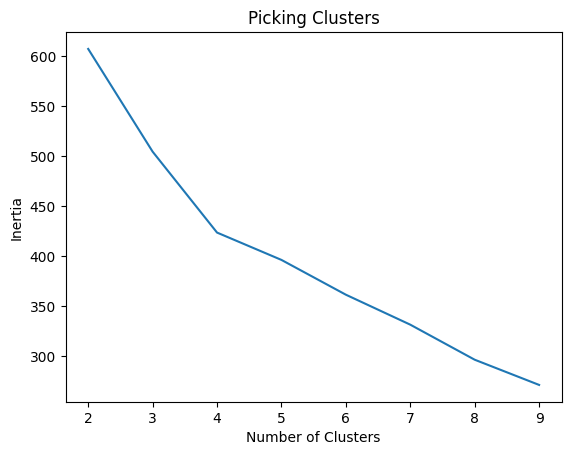

In [99]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Picking Clusters")
plt.show()

In [100]:
kmeans = KMeans(n_clusters=4, random_state=42)
author_features["cluster"] = kmeans.fit_predict(X_scaled)

In [101]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, author_features["cluster"])
print(sil_score)

0.1831121867873093


In [102]:
author_features.groupby("cluster").mean()

,articles,avg_sentiment,bullish_rate,bearish_rate,avg_return,avg_signal_return,accuracy,long_term_rate,volatility
cluster,,,,,,,,,
0,112.416667,0.029214,0.366266,0.337052,0.017885,0.001142,0.302213,0.316648,0.094184
1,150.827586,-0.172367,0.115360,0.287727,-0.002631,-0.000296,0.359756,0.244671,0.097425
2,901.666667,-0.002743,0.016709,0.019452,0.021397,0.000173,0.357022,0.014314,0.104291
3,67.333333,-0.474622,0.139995,0.614617,0.028458,-0.021811,0.222015,0.215848,0.102571


In [103]:
author_features["cluster"].value_counts()

cluster
1    29
0    24
2    18
3     9
Name: count, dtype: int64

The silhouette score of 0.18 suggests weak clustering but the model was still able to find clusters. This makes sense because we would expect most authors to be somewhat similar in nature. Cluster 2 looks like very neutral articles that just state facts rather than say anything meaningful, cluster 0 looks like more analysis focused publishers that have strong directional opinions, 1 looks slightly bearish and 3 looks very bearish.

In [104]:
for c in sorted(author_features["cluster"].unique()):
    print("Cluster", c)
    print(author_features[author_features["cluster"] == c].index.tolist())
    print()

Cluster 0
['Alex Furno', 'BenzingaStaffJ', 'BenzingaStaffL', 'Brett Hershman', 'Chris Dier-Scalise', 'Daniel Hayden IV', 'Dave Royse', 'David Johnson', 'Delores Land', 'Dwight Einhorn', 'Elizabeth Balboa', 'Eric Niederer', 'Erika Janowicz', 'Jim Swanson', 'Manikandan Raman', 'Matthew Kanterman', 'Phil Marsh', 'Priya Nigam', 'R. Chandrasekaran', 'Roger Nachman', 'Shanthi Rexaline', 'Steven Anfield', 'Tanzeel Akhtar', 'Zacks']

Cluster 1
['Benzinga News Desk', 'Benzinga Staff', 'Benzinga Staff 5', 'Benzinga Staff Writer', 'BenzingaStaffB', 'Bud Fox', 'Craig Jones', 'ETF Professor', 'Emily Austin', 'Ezra Schwarzbaum', 'Gordon Wilcox', 'Jayson Derrick', 'John Seward', 'Jonathan Chen', 'Kevin Riley', 'Louis Bedigian', 'Mark Meadows', 'Michael J. Zerinskas', 'Monica Gerson', 'Neer Varshney', 'Nelson Hem', 'Nic Chahine', 'Ritesh Anan', 'Scott Rubin', 'Spencer Israel', 'Taylor Cox', 'Wayne Duggan', 'inthemoneystocks', 'webmaster']

Cluster 2
['Allie Wickman', 'Benzinga Newdesk', 'Benzinga News

In [105]:
data.columns

Index(['headline', 'url', 'publisher', 'published_at', 'ticker',
       'Headline_Class_Prediction', 'total_article_count', 'publisher_size',
       'return_7d', 'return_30d', 'return_6m', 'article_text', 'finbert_label',
       'finbert_score', 'sentiment_encoded', 'long_term', 'movement',
       'accuracy', 'signal_return_30d', 'signal_return_7d',
       'signal_return_6m'],
      dtype='object')

In [107]:
author_features_2 = data.groupby("publisher").agg(
    total_articles=("total_article_count", "max"),
    
    avg_sentiment=("sentiment_encoded", "mean"),
    bullish_rate=("sentiment_encoded", lambda x: (x == 1).mean()),
    bearish_rate=("sentiment_encoded", lambda x: (x == -1).mean()),
    
    prediction_rate=("Headline_Class_Prediction", "mean"),
    
    avg_signal_7d=("signal_return_7d", "mean"),
    avg_signal_30d=("signal_return_30d", "mean"),
    avg_signal_6m=("signal_return_6m", "mean"),
    
    avg_return_30d=("return_30d", "mean"),
    volatility=("return_30d", "std"),
    
    long_term_rate=("long_term", "mean")
)

In [108]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(author_features_2)

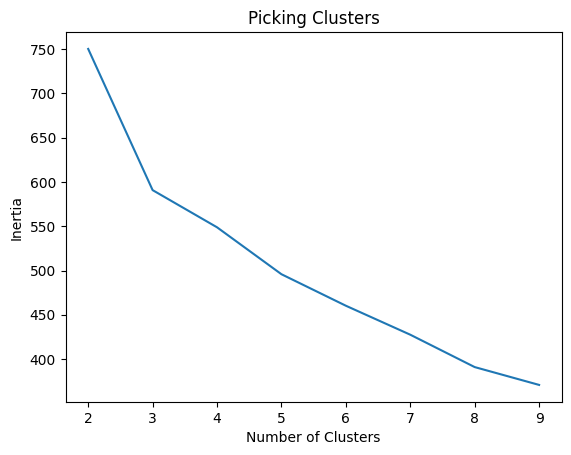

In [109]:
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Picking Clusters")
plt.show()

In [111]:
kmeans = KMeans(n_clusters=3, random_state=42)
author_features_2["cluster"] = kmeans.fit_predict(X_scaled)

In [112]:
sil_score = silhouette_score(X_scaled, author_features_2["cluster"])
print(sil_score)

0.18749712869405408


In [113]:
author_features_2.groupby("cluster").mean()

,total_articles,avg_sentiment,bullish_rate,bearish_rate,prediction_rate,avg_signal_7d,avg_signal_30d,avg_signal_6m,avg_return_30d,volatility,long_term_rate
cluster,,,,,,,,,,,
0,134.078947,-0.050193,0.294872,0.345064,0.312821,0.000102,0.000899,-0.003898,0.006629,0.093790,0.332015
1,113.200000,-0.447420,0.126488,0.573908,0.649183,-0.007357,-0.019278,-0.095771,0.022372,0.118585,0.198034
2,699.593750,-0.069904,0.038330,0.108234,0.434753,0.000401,-0.000492,-0.004017,0.016206,0.098007,0.071823


In [114]:
author_features_2["cluster"].value_counts()

cluster
0    38
2    32
1    10
Name: count, dtype: int64

In [115]:
for c in sorted(author_features_2["cluster"].unique()):
    print("Cluster", c)
    print(author_features_2[author_features_2["cluster"] == c].index.tolist())
    print()

Cluster 0
['Alex Furno', 'Benzinga Staff Writer', 'BenzingaStaffB', 'BenzingaStaffJ', 'BenzingaStaffL', 'Brett Hershman', 'Bud Fox', 'Chris Dier-Scalise', 'Dave Royse', 'David Johnson', 'Delores Land', 'Dwight Einhorn', 'ETF Professor', 'Elizabeth Balboa', 'Emily Austin', 'Eric Niederer', 'Erika Janowicz', 'Gordon Wilcox', "Jake L'Ecuyer", 'Jayson Derrick', 'Jim Swanson', 'John Seward', 'Jonathan Chen', 'Kevin Riley', 'Manikandan Raman', 'Mark Meadows', 'Matthew Kanterman', 'Phil Marsh', 'Priya Nigam', 'R. Chandrasekaran', 'Ritesh Anan', 'Roger Nachman', 'Shanthi Rexaline', 'Spencer Israel', 'Steven Anfield', 'Tanzeel Akhtar', 'Wayne Duggan', 'Zacks']

Cluster 1
['Bill Haddad', 'FreightWaves', 'Garrett Cook', 'JJ Kinahan', 'Javier Hasse', 'Joel Elconin', 'Laura Brodbeck', 'Neer Varshney', 'Scott Rubin', 'Tim Parker']

Cluster 2
['Allie Wickman', 'Benzinga Newdesk', 'Benzinga News Desk', 'Benzinga Newsdesk', 'Benzinga Staff', 'Benzinga Staff 5', 'Benzinga_Newsdesk', 'Benzinga\u2003Newsd